# 🏢 Contexte client

Client :  
Une grande entreprise de télécommunications.  
Problème :  
Le client constate un taux de résiliation (churn) élevé .  
Ils veulent anticiper quels clients risquent de partir afin de mieux cibler les actions de rétention.  

Mission :  
👉 Proposer une démarche data science pour prédire le churn des clients.   
👉 Identifier les variables qui expliquent le plus ce churn.  
👉 Donner des pistes business actionnables.

# Cadrage et enjeux
Actions:  
- Reformulation de la problématique : ***“Prédire la probabilité de churn pour cibler une action de rétention.”***  
- Enjeux business : baisse du churn, priorisation des campagnes, ROI des offres.  
- Contraintes usuelles : budget de contact limité, faux positifs coûteux, données hétérogènes.  
- Hypothèses :variables observées avant la résiliation.  

Demarche:  
- Objectif : estimer 𝑃(churn) à horizon H pour chaque client.  
- Décision d'action de rétention : contacter le top-k% des clients classés à risque.  
- Capacité : k ≈ 5–20% (à ajuster selon contraintes client).  
- KPI business : churn évité, ROI campagne de retention.  
- KPI data : Precision@k, Recall@k, Lift@k, PR-AUC, calibration.



## 1. Chargement des données

In [145]:
#import the libraries
from sklearn.model_selection import StratifiedKFold, train_test_split, GroupKFold, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, precision_recall_curve, roc_curve
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import xgboost as xgb
from sklearn.inspection import permutation_importance
import numpy as np, pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [105]:
import kagglehub
# Download the Telco Customer Churn dataset from Kaggle
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\okouo\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [106]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [107]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#===PARAMETRES===
Target="Churn"
DATE_COL    = None                 #pas dispo
ID_COL      = "customerID"             
POS_LABEL   = 1                    # valeur "churn"
TOP_K_RATE  = 0.10                 # pour les métriques top-k (ex: top 10% clients)


## 2. EDA

### 2.1 Aperçu général du dataset

In [108]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [109]:
df.info()
df.describe()
#df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [110]:
# Normalisation cible
df[Target] = df[Target].replace({"Yes": 1, "No": 0})

C:\Users\okouo\AppData\Local\Temp\ipykernel_7664\2267425752.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[Target] = df[Target].replace({"Yes": 1, "No": 0})


In [111]:
print("Type:", df["Churn"].dtype)
print("Taux de churn global:", df[Target].mean().round(3))

Type: int64
Taux de churn global: 0.265


<Axes: title={'center': 'Répartition churn (0=non,1=oui)'}, xlabel='Churn'>

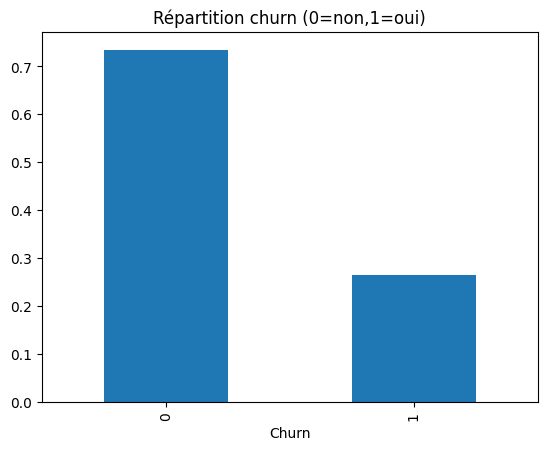

In [112]:
df[Target].value_counts(normalize=True).plot(kind="bar", title="Répartition churn (0=non,1=oui)")


In [113]:
#Récapitulatif du dataset

print("Shape:", df.shape)
print("\nTypes (compte):")
print(df.dtypes.value_counts())

# Colonnes clés présentes ?
Target, DATE_COL, ID_COL
print("\nColonnes présentes ?")
print("TARGET_COL in df:", Target in df.columns)
print("DATE_COL in df:", DATE_COL in df.columns)
print("ID_COL in df:", ID_COL in df.columns)

# Taux de churn

print("\nTaux de churn global:", round(df[Target].mean(), 4))
print("\nRépartition churn (counts):")
print(df[Target].value_counts())
print("\nRépartition churn (ratio):")
print(df[Target].value_counts(normalize=True).round(4))


Shape: (7043, 21)

Types (compte):
object     17
int64       3
float64     1
Name: count, dtype: int64

Colonnes présentes ?
TARGET_COL in df: True
DATE_COL in df: False
ID_COL in df: True

Taux de churn global: 0.2654

Répartition churn (counts):
Churn
0    5174
1    1869
Name: count, dtype: int64

Répartition churn (ratio):
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


On a bien un taux de churn important (26,5%)

### 2.2 Valeurs manquantes & conversion  

Objectif : repérer les NA “classiques” et les “faux NA” (chaînes vides), et voir si une colonne object est en fait numérique (typiquement TotalCharges).

In [114]:
print("===  Taux de NA (top 20) ===")
na_rate = df.isna().sum().sort_values(ascending=False)
display(na_rate)

print("\n===  Taux de chaînes vides ou espaces (dans les colonnes object) ===")
obj_cols = df.select_dtypes(include="object").columns.tolist()
blank_rate = (df[obj_cols]
              .apply(lambda s: s.astype(str).str.strip().eq("").mean()))
blank_rate = blank_rate.sort_values(ascending=False)
display(blank_rate)

print("\n===  Colonnes object 'numérisables' (détection automatique) ===")
num_like = {}
df_preview = df.copy()
for col in obj_cols:
    s = df[col].astype(str).str.strip().replace({"": np.nan})
    coerced = pd.to_numeric(s, errors="coerce")
    conv_rate = coerced.notna().mean()
    # Heuristique: si >95% convertible et >10 modalités, c’est probablement une variable numérique mal typée
    if conv_rate > 0.95 and df[col].nunique(dropna=True) > 10:
        num_like[col] = round(conv_rate, 4)
        df_preview[col] = coerced


print("Objets numérisables (colonne: taux_conversion_non_NA):")
print(num_like if num_like else "(aucune détectée)")

print("\nTypes si on convertissait ces colonnes (aperçu):")
print(df_preview.dtypes.value_counts())

print("\n===  Doublons d'identifiants ===")

#Pourquoi on fait ça ?
#Pas de doublons → OK
#Doublons vrais → erreurs à dédoublonner (supprimer ou garder la dernière occurrence).
#Doublons logiques (ex : un client peut avoir plusieurs lignes si plusieurs abonnements) → à décider avec le business : 
#on se place au niveau client ou au niveau contrat ?

if ID_COL in df.columns:
    dup_ids = df[ID_COL].duplicated(keep=False).sum()
    print(f"Nombre de lignes avec ID dupliqué: {dup_ids}")
    if dup_ids > 0:
        display(df[df[ID_COL].duplicated(keep=False)]
                .sort_values(ID_COL)
                .head(10))
else:
    print("Pas de colonne ID pour vérifier les doublons.")

===  Taux de NA (top 20) ===


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


===  Taux de chaînes vides ou espaces (dans les colonnes object) ===


TotalCharges        0.001562
customerID          0.000000
gender              0.000000
Dependents          0.000000
Partner             0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
PhoneService        0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
StreamingTV         0.000000
TechSupport         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
dtype: float64


===  Colonnes object 'numérisables' (détection automatique) ===
Objets numérisables (colonne: taux_conversion_non_NA):
{'TotalCharges': np.float64(0.9984)}

Types si on convertissait ces colonnes (aperçu):
object     16
int64       3
float64     2
Name: count, dtype: int64

===  Doublons d'identifiants ===
Nombre de lignes avec ID dupliqué: 0


Analyse:  
- Pas de NA classiques → dataset propre.
- TotalCharges : écrit en object, mais convertible en numérique, quelques vides (0.15% ≈ 11 lignes sur 7043).→ on convertira en float et imputera la médiane ou supprimera les lignes (négligeable).
- Pas de doublons d’ID → ok.

👉 donc côté qualité : très peu de souci, juste traiter TotalCharges.

### 2.3 Imputation de TotalCharges

In [115]:
# Convertir TotalCharges en float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

mask = df["TotalCharges"].isna()
print("Nb vides TotalCharges:", mask.sum(), "| part:", round(mask.mean(), 4))

print("\nTenure des lignes avec TotalCharges vide :")
print(df.loc[mask, "tenure"].value_counts())

print("\nStatistiques tenure & monthly pour ces lignes :")
print(df.loc[mask, ["tenure", "MonthlyCharges"]].describe())

print("\nPart de tenure==0 parmi les vides TotalCharges :")
print(round((df.loc[mask, "tenure"]==0).mean(), 4))

Nb vides TotalCharges: 11 | part: 0.0016

Tenure des lignes avec TotalCharges vide :
tenure
0    11
Name: count, dtype: int64

Statistiques tenure & monthly pour ces lignes :
       tenure  MonthlyCharges
count    11.0       11.000000
mean      0.0       41.418182
std       0.0       23.831484
min       0.0       19.700000
25%       0.0       20.125000
50%       0.0       25.750000
75%       0.0       58.975000
max       0.0       80.850000

Part de tenure==0 parmi les vides TotalCharges :
1.0


In [ ]:
#Les vides correspondent enfait à tenure=0 (clients tout juste arrivés,logique)
#On met plutôt la valeur 0$ 
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

### 2.4 Corrélations brutes / check fuite
Objectif : voir si certaines variables numériques sont ultra-corrélées au churn → possible fuite ou indicateur très fort.  

*Qu’est-ce qu’une fuite de données (data leakage) ?*  
*C’est quand on utilise, pour entraîner un modèle, une information qui n’est pas disponible au moment où on doit prédire.*  
*Résultat : le modèle paraît excellent en test, mais il est inutilisable en prod*

In [116]:
# Corrélations numériques avec la cible
corrs = (
    df.select_dtypes(include="number")
      .corr(numeric_only=True)[Target]
)
print("Corrélations avec churn:")
print(corrs)

Corrélations avec churn:
SeniorCitizen     0.150889
tenure           -0.352229
MonthlyCharges    0.193356
TotalCharges     -0.199484
Churn             1.000000
Name: Churn, dtype: float64


- tenure est le facteur n°1 (corr ≈ −0.35) → plus le client est ancien, moins il churn.
- MonthlyCharges corrèle positivement (≈ +0.19) → facture mensuelle élevée = risque ↑.
- TotalCharges corrèle négativement (≈ −0.20) car très lié à tenure (plus on reste, plus on a payé au total) → colinéarité probable avec tenure.
- SeniorCitizen effet modéré (+0.15).  

Rien ne crie “fuite de données” pour l’instant.

### 2.5 Variables Catégorielles

In [122]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Nb de variables catégorielles:", len(cat_cols))


def churn_rate_by_category(col):
    tab = df.groupby(col)[Target].mean().sort_values(ascending=False)
    return tab


for c in cat_cols:
    if c in df.columns:
        print(f"\n=== {c} ===")
        print(churn_rate_by_category(c))


Nb de variables catégorielles: 16

=== customerID ===
customerID
0013-EXCHZ    1.0
0004-TLHLJ    1.0
9985-MWVIX    1.0
9986-BONCE    1.0
9992-RRAMN    1.0
             ... 
9950-MTGYX    0.0
9953-ZMKSM    0.0
9955-QOPOY    0.0
9957-YODKZ    0.0
9958-MEKUC    0.0
Name: Churn, Length: 7043, dtype: float64

=== gender ===
gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64

=== Partner ===
Partner
No     0.329580
Yes    0.196649
Name: Churn, dtype: float64

=== Dependents ===
Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64

=== PhoneService ===
PhoneService
Yes    0.267096
No     0.249267
Name: Churn, dtype: float64

=== MultipleLines ===
MultipleLines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: Churn, dtype: float64

=== InternetService ===
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64

=== OnlineSecurity ===
OnlineSecurity
No 

Variables sociodémographiques :  
Partner, Dependents → avoir famille/dépendants protège contre le churn (~15–20% vs ~33%).  
gender : effet quasi nul (26.9 vs 26.1).  
  
Services :  
InternetService = gros facteur : Fibre ≈ 42% churn (!), DSL ≈ 19%, pas d’internet ≈ 7%.  
OnlineSecurity, TechSupport, DeviceProtection : “pas d’option” → >39–41% churn, vs ~15% si abonné.  
Les clients sans Internet → très peu de churn (mais peut-être moins de valeur aussi).  
  
Engagement :  
Contract : Month-to-month (sans engagement) = 42% churn, One year ≈ 11%, Two year ≈ 3%.  
PaperlessBilling : oui = 33%, non = 16%.  
PaymentMethod : Electronic check = 45% churn (!), vs <20% pour auto-paiement.  
  
👉 Donc, les variables qui ressortent déjà comme clés :  
tenure, MonthlyCharges, Contract type, InternetService, PaymentMethod, Support/Options.

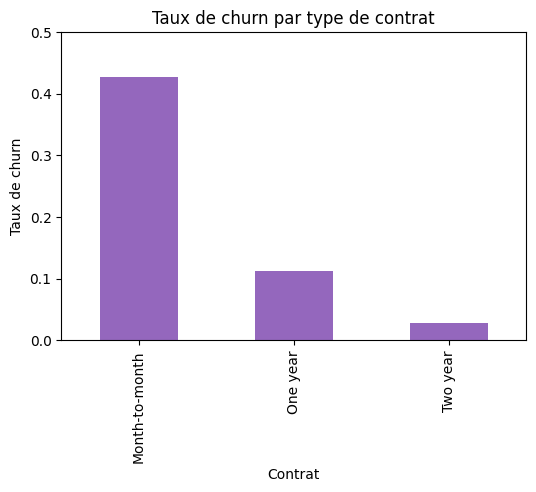

In [127]:
#Visualisation

contract_rates = df.groupby("Contract")[Target].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
contract_rates.plot(kind="bar", color="#9467bd")
plt.title("Taux de churn par type de contrat")
plt.ylabel("Taux de churn")
plt.xlabel("Contrat")
plt.ylim(0,0.5)
plt.show()

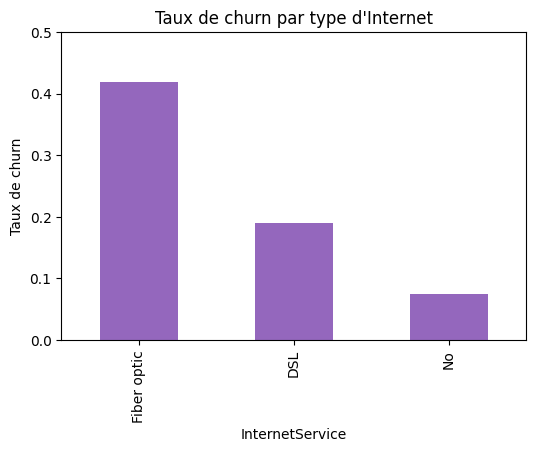

In [126]:
internet_rates = df.groupby("InternetService")[Target].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
internet_rates.plot(kind="bar", color="#9467bd")
plt.title("Taux de churn par type d'Internet")
plt.ylabel("Taux de churn")
plt.xlabel("InternetService")
plt.ylim(0,0.5)
plt.show()

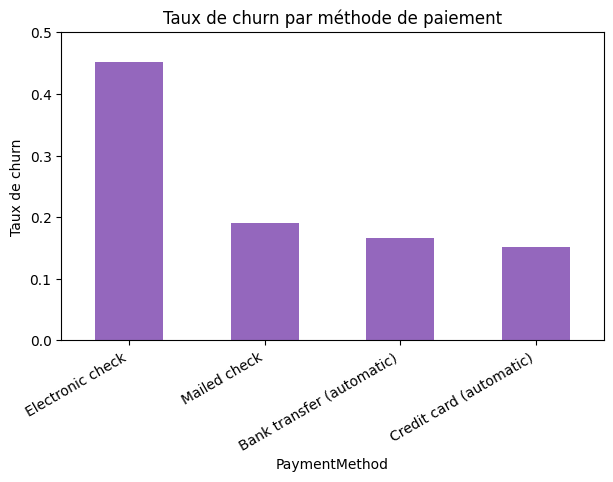

In [ ]:
payment_rates = df.groupby("PaymentMethod")[Target].mean().sort_values(ascending=False)

plt.figure(figsize=(7,4))
payment_rates.plot(kind="bar", color="#9467bd")
plt.title("Taux de churn par méthode de paiement")
plt.ylabel("Taux de churn")
plt.xlabel("PaymentMethod")
plt.xticks(rotation=30, ha="right")
plt.ylim(0,0.5)
plt.show()

## 3. Preparation+Split+Baseline

### 3.1 Preparation

In [128]:
#On retire l'ID des features
drop_cols = [ID_COL] 

#Séparation X/y + types
X = df.drop(columns=[Target] + drop_cols)
y = df[Target].astype(int)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Shapes X/y:", X.shape, y.shape)
print("Nb num:", len(num_cols), "| Nb cat:", len(cat_cols))
print("Exemples num:", num_cols[:5])
print("Exemples cat:", cat_cols[:5])


Shapes X/y: (7043, 19) (7043,)
Nb num: 4 | Nb cat: 15
Exemples num: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Exemples cat: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines']


### 3.2 Split train/test

In [135]:
#Split train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y, # pour conserver la répartition de la cible
    random_state=RANDOM_STATE
)

print("Shapes — X_train / X_test:", X_train.shape, X_test.shape)
print("Shapes — y_train / y_test:", y_train.shape, y_test.shape)

def summarize_split(name, y):
    return pd.Series({
        "n": len(y),
        "churn_rate": float(y.mean()),
        "n_pos": int((y==1).sum()),
        "n_neg": int((y==0).sum())
    })

print("\nRépartition de la cible :")
split_summary = pd.DataFrame({
    "train": summarize_split("train", y_train),
    "test" : summarize_split("test",  y_test)
})
display(split_summary)

# On garde la liste des colonnes numériques / catégorielles pour plus tard
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print("\nNb num / cat:", len(num_cols), "/", len(cat_cols))


Shapes — X_train / X_test: (5634, 19) (1409, 19)
Shapes — y_train / y_test: (5634,) (1409,)

Répartition de la cible :


,train,test
n,5634.000000,1409.000000
churn_rate,0.265353,0.265436
n_pos,1495.000000,374.000000
n_neg,4139.000000,1035.000000



Nb num / cat: 4 / 15


### 3.3 Pretraitement en Pipeline et Baseline models

In [147]:
# 1) Prétraitements
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))  # important avec sparse
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

# 2) Modèles
models = {
    "dummy_stratified": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),                           #baseline sans intelligence.
    "logreg": LogisticRegression(max_iter=2000, solver="liblinear", class_weight=None, random_state=RANDOM_STATE),   #liblinear = solver robuste et adapté au sparse binaire.unbalanced = on garde les classes telles quelles, car le déséquilibre n’est pas dramatique.
    # Variante pour comparer  :
    # "logreg_balanced": LogisticRegression(
    #     max_iter=2000, solver="liblinear", class_weight="balanced", random_state=42
    # )
}

def eval_model(pipe, X_tr, y_tr, X_te, y_te, label="model", top_rate=TOP_K_RATE):
    pipe.fit(X_tr, y_tr)
    proba_tr = pipe.predict_proba(X_tr)[:, 1]
    proba_te = pipe.predict_proba(X_te)[:, 1]

    # métriques globales
    auc_tr = roc_auc_score(y_tr, proba_tr)
    auc_te = roc_auc_score(y_te, proba_te)
    ap_te  = average_precision_score(y_te, proba_te)
    brier  = brier_score_loss(y_te, proba_te)

    # recall@top-k (k = top_rate%)
    k = int(np.ceil(len(proba_te) * top_rate))
    top_idx = np.argsort(-proba_te)[:k]
    recall_at_k = y_te.iloc[top_idx].sum() / y_te.sum()
    capture_mult = (y_te.iloc[top_idx].mean() / y_te.mean()) if y_te.mean() > 0 else np.nan

    return {
        "model": label,
        "auc_tr": auc_tr,
        "auc_te": auc_te,
        "ap_te": ap_te,
        "brier_te": brier,
        "recall@top10%": recall_at_k,
        "lift@top10%": capture_mult
    }, proba_te, pipe

results = []
fitted = {}
for name, clf in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("clf", clf)])
    m, proba, fitted[name] = eval_model(pipe, X_train, y_train, X_test, y_test, name)
    results.append(m)

res_df = pd.DataFrame(results).sort_values("auc_te", ascending=False)
print("=== Résultats baselines ===")
display(res_df)


=== Résultats baselines ===


,model,auc_tr,auc_te,ap_te,brier_te,recall@top10%,lift@top10%
1,logreg,0.849310,0.842013,0.633561,0.138050,0.280749,2.805496
0,dummy_stratified,0.510467,0.516253,0.272340,0.378282,0.128342,1.282512


gap clair entre Dummy et LogReg, donc le modèle LogReg capte bien de l’info.

| Colonne               | Définition                                                                                                                                           | Lecture sur nos résultats                                                                     |
| --------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------- |
| **model**             | Nom du modèle testé                                                                                                                                  | `dummy_stratified` = référence aléatoire, `logreg` = régression logistique                    |
| **auc\_tr / auc\_te** | AUC ROC (aire sous la courbe ROC). Mesure la capacité du modèle à classer les churners plus haut que les non-churners (0.5 = hasard, 1.0 = parfait). | `auc_tr = 0.849`, `auc_te = 0.842` → le modèle généralise bien, \~84% de bonnes distinctions. |
| **ap\_te**            | Average Precision (aire sous la courbe Précision–Rappel). Pertinent pour classes déséquilibrées.                                                     | `0.634` vs `0.272` pour Dummy → bien meilleur que le hasard.                                  |
| **brier\_te**         | Brier Score (erreur quadratique sur les probabilités). Plus petit = meilleur (0 parfait).                                                            | `0.138` vs `0.378` pour Dummy → probabilités bien calibrées.                                  |
| **recall\@top10%**    | Rappel sur les **10% de clients scorés les plus à risque**.                                                                                          | `0.28` → si on cible 10% de la base, on récupère 28% de tous les churners réels.              |
| **lift\@top10%**      | Gain par rapport au hasard : taux de churn dans le top 10% / taux de churn global.                                                                   | `2.8` → le ciblage est **≈3x plus efficace** qu’une campagne aléatoire.                       |


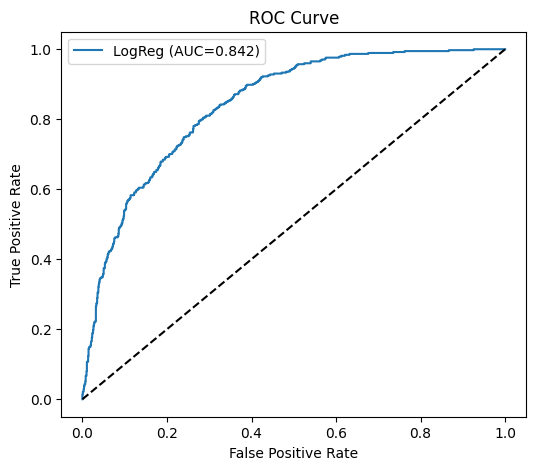

In [139]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

proba = fitted["logreg"].predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"LogReg (AUC={auc:.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


AUC = 0.84 → si je prends un client au hasard qui a churné et un qui n’a pas churné, le modèle a 84% de chances de donner un score plus haut au churner.
👉 Ça prouve que le modèle discrimine bien.

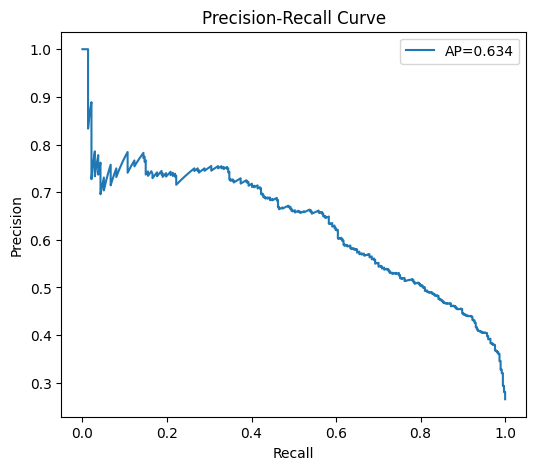

In [140]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP={ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


La baseline aléatoire aurait une AP ≈ taux de churn (0.27).

Ici AP = 0.63 → le modèle fait plus de 2x mieux que le hasard.  
👉 Ça veut dire que si on cible les plus gros scores, on a vraiment beaucoup de vrais churners.

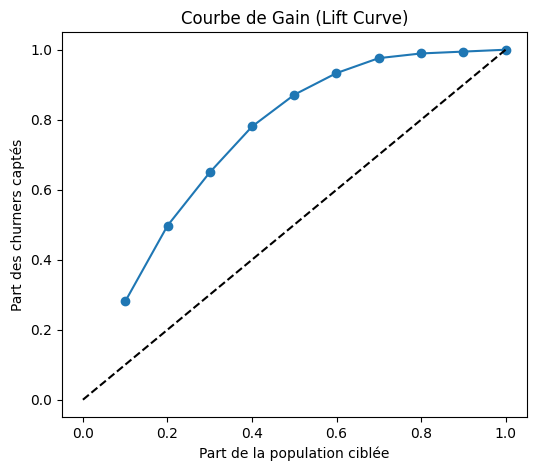

In [142]:
import numpy as np
import pandas as pd

df_lift = pd.DataFrame({"y": y_test, "p": proba}).sort_values("p", ascending=False)
df_lift["decile"] = pd.qcut(df_lift["p"].rank(method="first", ascending=False), 10, labels=False)

lift_table = df_lift.groupby("decile").agg(
    n=("y","size"), 
    churners=("y","sum")
).reset_index().sort_values("decile")

lift_table["cum_churners"] = lift_table["churners"].cumsum()
lift_table["cum_rate"] = lift_table["cum_churners"] / lift_table["churners"].sum()
lift_table["pop_share"] = lift_table["n"] / lift_table["n"].sum()
lift_table["cum_pop"] = lift_table["pop_share"].cumsum()

plt.figure(figsize=(6,5))
plt.plot(lift_table["cum_pop"], lift_table["cum_rate"], marker="o")
plt.plot([0,1],[0,1], "k--")
plt.xlabel("Part de la population ciblée")
plt.ylabel("Part des churners captés")
plt.title("Courbe de Gain (Lift Curve)")
plt.show()


Grâce au modèle, en ciblant seulement 20% des clients les plus à risque, on capture déjà la moitié des clients qui allaient partir. Ça prouve que le modèle permet de concentrer les efforts de rétention là où ils sont le plus utiles.

### 3.4 Feature Importance

In [ ]:
# On récupère le modèle logreg déjà entraîné
logreg_pipe = fitted["logreg"]

# 1) Extraire les noms de toutes les features après preprocessing
feature_names = []

  # Numériques
feature_names.extend(num_cols)

  # Catégorielles encodées
oh = logreg_pipe.named_steps["preprocessor"].named_transformers_["cat"].named_steps["oh"]
cat_features = oh.get_feature_names_out(cat_cols)
feature_names.extend(cat_features)

feature_names

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender_Female',
 'gender_Male',
 'Partner_No',
 'Partner_Yes',
 'Dependents_No',
 'Dependents_Yes',
 'PhoneService_No',
 'PhoneService_Yes',
 'MultipleLines_No',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_DSL',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_Month-to-month',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_No',
 'PaperlessBilling_Yes',
 'PaymentMethod_Bank tran

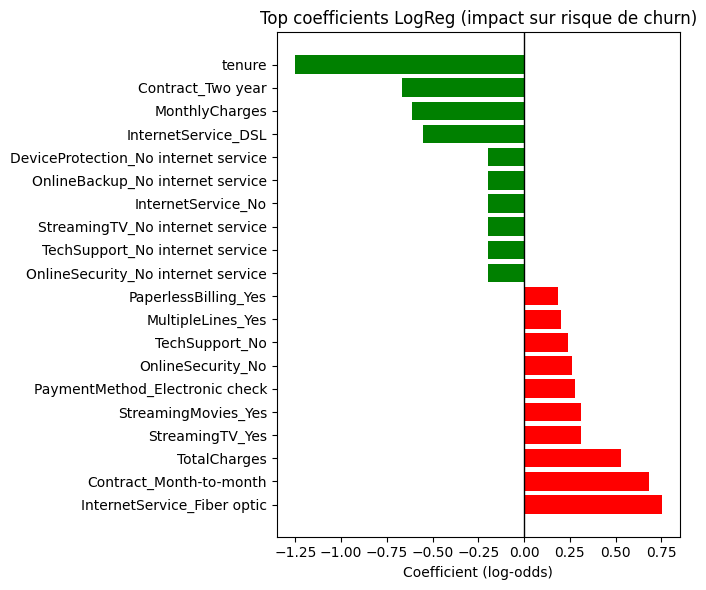

In [150]:
# 2) Récupérer les coefficients
clf = logreg_pipe.named_steps["clf"]
coefs = clf.coef_.flatten()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
}).sort_values("coef", ascending=False)

# 3) Visualiser top +/-
top_pos = coef_df.head(10)
top_neg = coef_df.tail(10)

plt.figure(figsize=(7,6))
plt.barh(top_pos["feature"], top_pos["coef"], color="red")
plt.barh(top_neg["feature"], top_neg["coef"], color="green")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top coefficients LogReg (impact sur risque de churn)")
plt.xlabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()




Nos analyses montrent que le churn est surtout lié au type de contrat, au type d’internet, à la méthode de paiement et à l’ancienneté. Ces leviers sont clairs pour le business : inciter à l’engagement, promouvoir certaines méthodes de paiement, améliorer la qualité perçue de la fibre.”

### 3.5 Comparaison à un modèle plus puissant

In [153]:
#Gradient Boosting & RandomForest (prétraitement dense pour modèles d’arbres)

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

# 1) Prétraitement dense (arbres : pas besoin de scaler les numériques)
num_pipe_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipe_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

prep_dense_tree = ColumnTransformer(
    transformers=[
        ("num", num_pipe_tree, num_cols),
        ("cat", cat_pipe_dense, cat_cols)
    ],
    sparse_threshold=0.0
)

# 2) Modèles à tester
models_tree = {
    "hgb": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_depth=None,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=42
    ),
    "rf_300": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced_subsample"
    )
}

def eval_model(pipe, X_tr, y_tr, X_te, y_te, label="model", top_rate=0.10):
    pipe.fit(X_tr, y_tr)
    proba_tr = pipe.predict_proba(X_tr)[:, 1]
    proba_te = pipe.predict_proba(X_te)[:, 1]

    auc_tr = roc_auc_score(y_tr, proba_tr)
    auc_te = roc_auc_score(y_te, proba_te)
    ap_te  = average_precision_score(y_te, proba_te)
    brier  = brier_score_loss(y_te, proba_te)

    k = int(np.ceil(len(proba_te) * top_rate))
    top_idx = np.argsort(-proba_te)[:k]
    recall_at_k = y_te.iloc[top_idx].sum() / y_te.sum()
    capture_mult = (y_te.iloc[top_idx].mean() / y_te.mean()) if y_te.mean() > 0 else np.nan

    return {
        "model": label,
        "auc_tr": auc_tr,
        "auc_te": auc_te,
        "ap_te": ap_te,
        "brier_te": brier,
        "recall@top10%": recall_at_k,
        "lift@top10%": capture_mult
    }, proba_te, pipe

results_tree = []
fitted_tree = {}

for name, clf in models_tree.items():
    pipe = Pipeline([("prep", prep_dense_tree), ("clf", clf)])
    m, proba, fitted_tree[name] = eval_model(pipe, X_train, y_train, X_test, y_test, name)
    results_tree.append(m)

res_tree_df = pd.DataFrame(results_tree).sort_values("auc_te", ascending=False)

# (Optionnel) comparaison côte-à-côte avec la logreg calculée plus tôt si res_df existe
try:
    print("=== Comparaison avec LogReg ===")
    display(pd.concat([res_df, res_tree_df], ignore_index=True).sort_values("auc_te", ascending=False))
except NameError:
    pass


=== Comparaison avec LogReg ===


,model,auc_tr,auc_te,ap_te,brier_te,recall@top10%,lift@top10%
0,logreg,0.849310,0.842013,0.633561,0.138050,0.280749,2.805496
2,hgb,0.908117,0.835435,0.644734,0.139196,0.283422,2.832215
3,rf_300,0.999851,0.822601,0.614543,0.145797,0.283422,2.832215
1,dummy_stratified,0.510467,0.516253,0.272340,0.378282,0.128342,1.282512


Nous avons comparé plusieurs modèles. La régression logistique atteint déjà un AUC de 0.84 et un AP de 0.63.
Les modèles plus complexes (Gradient Boosting, Random Forest) n’apportent pas de gain significatif, et la LogReg reste plus simple et interprétable.  
→ Nous privilégions donc la LogReg comme modèle de référence pour ce cas client

## 4. Simulation Business

On suppose  :

- Coût contact = 2 €
- Coût offre rétention = 10 €
- Revenu sauvé par churn évité = 120 €
- Taux d’acceptation offre = 35%

In [154]:
from sklearn.metrics import confusion_matrix, precision_recall_curve

# Hypothèses business
CONTACT_COST   = 2.0
OFFER_COST     = 10.0
REVENUE_SAVED  = 120.0
ACCEPT_RATE    = 0.35

# On utilise le meilleur modèle choisi (ici logreg)
best_model = fitted["logreg"]
proba_test = best_model.predict_proba(X_test)[:,1]

def business_gain(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    tp = ((pred==1) & (y_true==1)).sum()
    fp = ((pred==1) & (y_true==0)).sum()
    n_contact = (pred==1).sum()
    
    # Gain attendu
    gain = tp * ACCEPT_RATE * REVENUE_SAVED
    cost = n_contact * (CONTACT_COST + OFFER_COST)
    return gain - cost

# On balaye plusieurs seuils
thresholds = np.linspace(0.1,0.9,81)
scores = [business_gain(y_test.values, proba_test, t) for t in thresholds]

best_idx = int(np.argmax(scores))
best_thr = thresholds[best_idx]
best_gain = scores[best_idx]

print(f"Seuil optimal business: {best_thr:.2f}")
print(f"Gain attendu sur l’échantillon test: {best_gain:.0f} €")

# Matrice de confusion au seuil optimal
pred_opt = (proba_test >= best_thr).astype(int)
cm = confusion_matrix(y_test, pred_opt)
cm_df = pd.DataFrame(cm, index=["Actual 0","Actual 1"], columns=["Pred 0","Pred 1"])
print("\nMatrice de confusion au seuil optimal:")
display(cm_df)


Seuil optimal business: 0.27
Gain attendu sur l’échantillon test: 5478 €

Matrice de confusion au seuil optimal:


,Pred 0,Pred 1
Actual 0,759,276
Actual 1,81,293


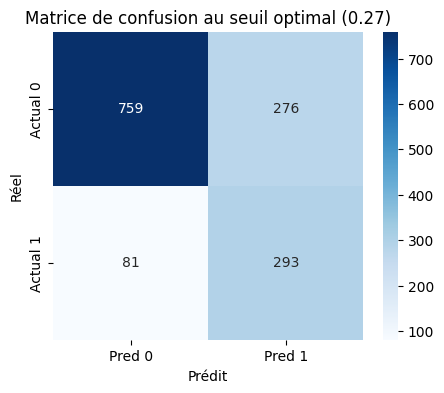

In [155]:
# Matrice de confusion déjà calculée
cm = confusion_matrix(y_test, pred_opt)
labels = ["Non churn", "Churn"]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0","Pred 1"],
            yticklabels=["Actual 0","Actual 1"])
plt.title("Matrice de confusion au seuil optimal (0.27)")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()


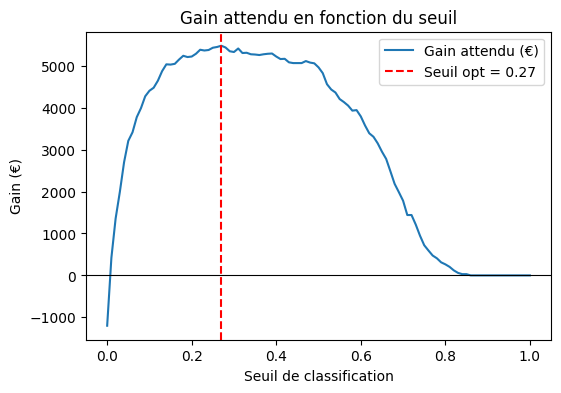

In [156]:
thresholds = np.linspace(0.0,1.0,101)
scores = [business_gain(y_test.values, proba_test, t) for t in thresholds]

plt.figure(figsize=(6,4))
plt.plot(thresholds, scores, label="Gain attendu (€)")
plt.axvline(best_thr, color="red", linestyle="--", label=f"Seuil opt = {best_thr:.2f}")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Gain attendu en fonction du seuil")
plt.xlabel("Seuil de classification")
plt.ylabel("Gain (€)")
plt.legend()
plt.show()


# Conclusion

1. **Le modèle prédit une probabilité de churn pour chaque client**  
*Exemple : client A = 70% de risque, client B = 15%.*  
Si on mettait un seuil “naïf” à 0.5, on ne retiendrait que les clients avec >50% de probabilité → on en raterait beaucoup.  
  
2. **Budget limité → on ne peut pas contacter 100% des clients**  
Contacter toute la base serait trop coûteux et inutile (beaucoup de faux positifs).  
L’intérêt du modèle est donc de prioriser :  
on trie les clients du plus risqué au moins risqué,  
on décide de ne contacter que le top 10–20% scorés, selon le budget.  

3. **Pourquoi baisser le seuil ?**  
Un seuil bas (ex : 0.27 au lieu de 0.5) permet de capter plus de churners.  
Oui, on contacte aussi plus de faux positifs, mais tant que le gain attendu reste positif, c’est rentable.  
Dans notre simulation :  
à 0.27, on retient presque 80% des churners,  
le coût supplémentaire (faux positifs contactés) est largement compensé par le revenu sauvé des churners retenus.  

4. **Le lien avec le gain attendu**  
Gain attendu = revenu sauvé (churners détectés × probabilité de rester × revenu client) − coût des actions (contact + offre).  
Si le seuil est trop haut → on détecte peu de churners, donc peu de revenu sauvé.  
Si le seuil est trop bas → on contacte trop de faux positifs, le coût explose.  
Le seuil optimal (0.27) est celui qui maximise ce gain net → ≈ 5 500 € sur l’échantillon test.

5. **Nous avons constaté:**  
Ancienneté (tenure) protège contre le churn,  
les contrats sans engagement (month-to-month) affichent un taux de churn de plus de 40%,  
la méthode de paiement “Electronic check” est particulièrement risquée (~45%),  
les clients sans services additionnels (sécurité, support) sont plus volatiles,  
les nouveaux clients et une partie des clients fibre sont aussi plus exposés.  

**Ce qu’il reste à faire désormais**  
- Intégrer le score dans les outils métier (CRM, campagnes marketing).  
- Définir des actions différenciées par segment :  
proposer de l’engagement long aux contrats mensuels,  
inciter les clients Electronic check à passer au prélèvement automatique,  
offrir des services additionnels en essai aux clients sans options,  
soigner l’onboarding des nouveaux clients.  

- Mettre en place un suivi opérationnel : A/B tests pour mesurer l’efficacité réelle des campagnes, monitoring mensuel du modèle (drift, recalibrage).